# Lab 8 DuckDB
## CC3084 Data Science, Ciclo 2, 2026. Viajes de taxi de Nueva York

Integrantes: completar con los nombres del equipo.

Datos: viajes de taxis amarillos y verdes publicados por la TLC de Nueva York, enero de 2024 a agosto de 2026. Son 64 archivos Parquet y 121 millones de viajes. Los archivos no estan en el repositorio, se bajan con el script de descarga.

Cada consulta usada vive en la carpeta sql, con su objetivo y su fuente al inicio del archivo. En este notebook cada consulta se imprime antes de su resultado, y debajo de cada una esta la lectura del resultado y la decision que se tomo.

## Ejercicio 1. Preparacion del ambiente

1.1 y 1.2. El trabajo parte del repositorio del docente. La entrega es la direccion del fork del equipo, que se crea desde la pagina del repositorio base.

1.3. Con Docker Compose se levanto el servicio lab. Quedo corriendo en el puerto 8888, Jupyter respondio y los datos de la carpeta data se ven dentro del contenedor. El servicio de Metabase no se pudo construir en esta maquina porque el disco se lleno durante la construccion, asi que el tablero de este laboratorio se genero con Python. Las consultas de cada indicador quedaron en sql para llevarlas a Metabase.

1.4. Herramientas del ambiente: Python 3.11, DuckDB 1.5.5, JupyterLab 4.6.4, pandas, pyarrow, matplotlib y requests. Metabase con el controlador de DuckDB esta definido en su propio Dockerfile. La celda siguiente imprime las versiones del equipo donde se ejecuto el notebook. El contenedor trae las fijadas en requirements.txt, que son DuckDB 1.5.5, pandas 3.0.6 y pyarrow 25.0.1.

1.5. El procedimiento esta en el README.

1.6. Un ambiente reproducible hace que cualquier persona obtenga los mismos resultados con las mismas versiones. Sin eso, un analisis que funciona en una maquina puede fallar o dar otro numero en otra, y nadie sabe si la diferencia viene de los datos o de las herramientas. Tambien ahorra tiempo al sumar companeros nuevos y permite repetir el trabajo cuando lleguen datos nuevos.

### Proposito de cada carpeta
data raw guarda los archivos tal como se descargan y nunca se modifican. data processed guarda lo que se genera a partir de ellos, como la base de DuckDB. notebooks guarda los cuadernos de analisis. scripts guarda los programas que se corren desde la terminal, como la descarga y el benchmark. sql guarda las consultas, una por archivo. docs guarda las tablas y graficas que se llevan al informe. Dockerfile y docker-compose.yml definen el ambiente, y el README explica como usar todo.

In [1]:
import os, sys, time, warnings, subprocess, platform
from pathlib import Path
import duckdb, pandas as pd, numpy as np
import matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

SQL = Path("../sql")        # consultas documentadas
DOCS = Path("../docs")      # tablas y graficas que se llevan al informe
DOCS.mkdir(exist_ok=True)

# Herramientas disponibles en el ambiente
import matplotlib, pyarrow, requests
print("python    ", platform.python_version())
print("duckdb    ", duckdb.__version__)
print("pandas    ", pd.__version__)
print("pyarrow   ", pyarrow.__version__)
print("matplotlib", matplotlib.__version__)
print("requests  ", requests.__version__)

# Conexion en memoria. Los datos se leen de los archivos Parquet, no se importan.
con = duckdb.connect()
con.execute("SET memory_limit = '1500MB'")
con.execute("SET threads = 2")
con.execute("SET preserve_insertion_order = false")
con.execute(f"SET temp_directory = '{os.environ.get('LAB8_TEMP', '../data/processed/tmp')}'")
con.execute((SQL / "00_vistas.sql").read_text(encoding="utf8"))

def ejecutar(nombre):
    """Lee sql/<nombre>.sql, lo muestra, lo ejecuta y devuelve el resultado como tabla."""
    texto = (SQL / f"{nombre}.sql").read_text(encoding="utf8")
    print(texto.strip())
    inicio = time.perf_counter()
    resultado = con.sql(texto).df()
    print(f"-- tiempo: {time.perf_counter() - inicio:.1f} s")
    return resultado

python     3.10.11
duckdb     1.5.6
pandas     2.3.3
pyarrow    25.0.1
matplotlib 3.10.9
requests   2.34.2


## Ejercicio 2. Sistema de descarga

2.1. El script original estaba escrito para un solo anio, con el 2026 fijo en el nombre, la direccion y la carpeta de cada archivo. Eso era lo que habia que cambiar.

2.2 y 2.3. Los archivos de amarillos y verdes se guardan en data raw, en una carpeta por tipo y otra por anio.

2.4. Si el archivo ya existe y no esta vacio, el script lo omite.

2.6. Cambios hechos al script. El anio dejo de ser fijo y ahora todas las funciones lo reciben. Se agrego la opcion years para elegir los anios, con 2024, 2025 y 2026 como valor por defecto. Se agrego una comprobacion final que compara el tamano de cada archivo local con el que declara el servidor. El resumen ahora muestra tambien los archivos incompletos y el script termina con error si hay alguno.

La descarga se hizo por etapas con el mismo script, primero 2026, luego 2024 y 2025. Al repetir 2026 el script informo 16 archivos existentes y 0 descargados.

La celda siguiente muestra la ayuda del script y lo que hay en disco.

In [2]:
# Ejercicio 2: el script de descarga. Se muestra su ayuda y los archivos que quedaron en disco
print(subprocess.run([sys.executable, "../scripts/download_data.py", "--help"], capture_output=True, text=True).stdout)
archivos = sorted(Path("../data/raw").glob("*/*/*.parquet"))
resumen = pd.DataFrame({"archivo": [a.name for a in archivos], "tipo": [a.parts[-3] for a in archivos],
                        "anio": [a.parts[-2] for a in archivos], "mb": [a.stat().st_size / 1e6 for a in archivos]})
display(resumen.groupby(["tipo", "anio"]).agg(archivos=("archivo", "count"), mb=("mb", "sum")))

usage: download_data.py [-h] [--taxi {yellow,green,all}]
                        [--years YEARS [YEARS ...]]

Descarga los datos de taxis del NYC TLC.

options:
  -h, --help            show this help message and exit
  --taxi {yellow,green,all}
                        tipo de taxi a descargar (por defecto: all)
  --years YEARS [YEARS ...]
                        anios a descargar (por defecto: 2024 2025 2026)



archivos     mb
tipo   anio                 
green  2024        12  15.92
       2025        12  14.46
       2026         8   8.28
yellow 2024        12 693.00
       2025        12 829.97
       2026         8 511.45

2.5 y 2.7. Como se sabe que la descarga esta completa. Primero, para cada mes el script pregunta al servidor si el archivo existe. En 2024 y 2025 existen los doce meses de los dos tipos de taxi. En 2026 existen de enero a agosto, y septiembre a diciembre todavia no estan publicados por la TLC. Segundo, el tamano de cada archivo local coincide con el que declara el servidor, y el resumen final reporto 0 incompletos y 0 fallidos. Tercero, la descarga se escribe en un archivo temporal que solo se renombra al terminar, por eso no quedan archivos a medias. Cuarto, DuckDB cuenta 32 archivos por tipo, que son 12 mas 12 mas 8, y los metadatos de los archivos suman la misma cantidad de registros que un conteo directo.

## Ejercicio 3. Consultas directas sobre archivos Parquet

Las primeras consultas leen los archivos Parquet directamente, sin importarlos a una tabla. Despues se define una vista llamada viajes que une amarillos y verdes con los mismos nombres de columna. La vista tampoco copia datos, solo recuerda de donde leerlos.

La vista viajes esta en sql 00_vistas. Los nombres de las columnas se unificaron y se agrego el anio y el mes de cada archivo, sacados del nombre del archivo.

In [3]:
display(con.sql("DESCRIBE viajes").df()[["column_name", "column_type"]])

,column_name,column_type
0,tipo,VARCHAR
1,anio_archivo,INTEGER
2,mes_archivo,INTEGER
3,recogida,TIMESTAMP
4,entrega,TIMESTAMP
5,pasajeros,BIGINT
6,distancia_mi,DOUBLE
7,zona_origen,INTEGER
8,zona_destino,INTEGER
9,tipo_pago,BIGINT


In [4]:
r = ejecutar("03_01_archivos")
display(r)

-- Objetivo: Contar los archivos Parquet disponibles por tipo de taxi y anio.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet
SELECT tipo, anio, count(*) AS archivos
FROM (
    SELECT 'amarillo' AS tipo, regexp_extract(file, '(\d{4})-\d{2}\.parquet', 1) AS anio
    FROM glob('../data/raw/yellow/*/*.parquet') t(file)
    UNION ALL
    SELECT 'verde', regexp_extract(file, '(\d{4})-\d{2}\.parquet', 1)
    FROM glob('../data/raw/green/*/*.parquet') t(file)
)
GROUP BY tipo, anio
ORDER BY tipo, anio;
-- tiempo: 0.0 s


,tipo,anio,archivos
0,amarillo,2024,12
1,amarillo,2025,12
2,amarillo,2026,8
3,verde,2024,12
4,verde,2025,12
5,verde,2026,8


3.1. Hay 64 archivos, 32 por tipo de taxi. Son 12 de 2024, 12 de 2025 y 8 de 2026 para cada tipo.

In [5]:
r = ejecutar("03_02_registros_metadatos")
display(r)

-- Objetivo: Contar registros leyendo solo los metadatos de cada archivo, sin recorrer los datos.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet
SELECT 'amarillo' AS tipo, count(*) AS archivos, sum(num_rows) AS registros
FROM parquet_file_metadata('../data/raw/yellow/*/*.parquet')
UNION ALL
SELECT 'verde', count(*), sum(num_rows)
FROM parquet_file_metadata('../data/raw/green/*/*.parquet');
-- tiempo: 0.0 s


,tipo,archivos,registros
0,amarillo,32,"119,595,677.00"
1,verde,32,"1,588,707.00"


3.2. Hay 119,595,677 viajes amarillos y 1,588,707 verdes, en total 121.2 millones. Esta consulta tardo menos de un segundo porque solo lee el pie de cada archivo, donde Parquet guarda el numero de filas.

In [6]:
r = ejecutar("03_03_registros_conteo")
display(r)

-- Objetivo: Confirmar el numero de registros contandolos directamente en los archivos.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet
SELECT 'amarillo' AS tipo, count(*) AS registros FROM read_parquet('../data/raw/yellow/*/*.parquet', union_by_name = true)
UNION ALL
SELECT 'verde', count(*) FROM read_parquet('../data/raw/green/*/*.parquet', union_by_name = true);
-- tiempo: 0.1 s


,tipo,registros
0,amarillo,119595677
1,verde,1588707


El conteo directo da los mismos numeros que los metadatos. Se uso para confirmar. Decision: para conteos totales conviene usar los metadatos, que es mucho mas rapido.

In [7]:
r = ejecutar("03_04_columnas_tipos")
display(r)

-- Objetivo: Listar las columnas y sus tipos de dato de cada tipo de taxi.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet
SELECT 'amarillo' AS tipo, column_name AS columna, column_type AS tipo_dato
FROM (DESCRIBE SELECT * FROM read_parquet('../data/raw/yellow/*/*.parquet', union_by_name = true))
UNION ALL
SELECT 'verde', column_name, column_type
FROM (DESCRIBE SELECT * FROM read_parquet('../data/raw/green/*/*.parquet', union_by_name = true))
ORDER BY tipo, columna;
-- tiempo: 0.1 s


,tipo,columna,tipo_dato
0,amarillo,Airport_fee,DOUBLE
1,amarillo,DOLocationID,INTEGER
2,amarillo,PULocationID,INTEGER
3,amarillo,RatecodeID,BIGINT
4,amarillo,VendorID,INTEGER
5,amarillo,cbd_congestion_fee,DOUBLE
6,amarillo,congestion_surcharge,DOUBLE
7,amarillo,extra,DOUBLE
8,amarillo,fare_amount,DOUBLE
9,amarillo,improvement_surcharge,DOUBLE


3.3 y 3.4. Los amarillos tienen 21 columnas y los verdes 22. Las fechas son marcas de tiempo, las distancias y los montos son decimales, las zonas son enteros y la bandera de envio es texto. Las columnas de fecha se llaman distinto en cada taxi, tpep para amarillos y lpep para verdes, y los verdes tienen dos columnas propias, ehail_fee y trip_type. Decision: renombrar y unificar las columnas comunes en la vista.

In [8]:
r = ejecutar("03_05_esquema_por_anio")
display(r)

-- Objetivo: Ver en que anios aparece cada columna, para detectar cambios de esquema entre archivos.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet
SELECT tipo, columna, list_sort(list(DISTINCT anio)) AS anios_donde_aparece
FROM (
    SELECT 'amarillo' AS tipo, name AS columna, regexp_extract(file_name, '(\d{4})-\d{2}\.parquet', 1) AS anio
    FROM parquet_schema('../data/raw/yellow/*/*.parquet') WHERE name <> 'schema'
    UNION ALL
    SELECT 'verde', name, regexp_extract(file_name, '(\d{4})-\d{2}\.parquet', 1)
    FROM parquet_schema('../data/raw/green/*/*.parquet') WHERE name <> 'schema'
)
GROUP BY tipo, columna
HAVING count(DISTINCT anio) < 3
ORDER BY tipo, columna;
-- tiempo: 0.0 s


,tipo,columna,anios_donde_aparece
0,amarillo,cbd_congestion_fee,"[2025, 2026]"
1,amarillo,request_source,[2026]
2,verde,cbd_congestion_fee,"[2025, 2026]"
3,verde,request_source,[2026]


El esquema cambio con el tiempo. La columna cbd_congestion_fee aparece desde 2025 y request_source solo en 2026. Los archivos de 2024 no las tienen. Decision: leer con union_by_name para que DuckDB junte los archivos por nombre de columna y rellene con nulo donde falta.

In [9]:
r = ejecutar("03_06_muestra_amarillo")
display(r)

-- Objetivo: Ver una muestra de cinco registros de taxis amarillos.
-- Fuente: data/raw/yellow/2026/yellow_tripdata_2026-01.parquet
SELECT * FROM read_parquet('../data/raw/yellow/2026/yellow_tripdata_2026-01.parquet') LIMIT 5;


-- tiempo: 0.1 s


,VendorID,tpep_pickup_datetime,tpep_dropoff_datetime,passenger_count,trip_distance,RatecodeID,store_and_fwd_flag,PULocationID,DOLocationID,payment_type,fare_amount,extra,mta_tax,tip_amount,tolls_amount,improvement_surcharge,total_amount,congestion_surcharge,Airport_fee,cbd_congestion_fee
0,2,2026-01-13 15:40:33,2026-01-13 16:01:22,1,6.98,1,N,132,76,4,-29.60,0.00,-0.50,0.00,0.00,-1.00,-32.85,0.00,-1.75,0.00
1,2,2026-01-13 15:40:33,2026-01-13 16:01:22,1,6.98,1,N,132,76,4,29.60,0.00,0.50,0.00,0.00,1.00,32.85,0.00,1.75,0.00
2,2,2026-01-13 15:59:58,2026-01-13 16:51:48,1,17.59,2,N,132,90,1,70.00,0.00,0.50,16.44,7.46,1.00,100.40,2.50,1.75,0.75
3,2,2026-01-13 15:45:00,2026-01-13 15:53:49,1,1.16,1,N,100,163,1,10.00,0.00,0.50,2.95,0.00,1.00,17.70,2.50,0.00,0.75
4,2,2026-01-13 15:58:18,2026-01-13 16:20:58,1,2.63,1,N,163,75,1,21.20,0.00,0.50,6.49,0.00,1.00,32.44,2.50,0.00,0.75


In [10]:
r = ejecutar("03_06_muestra_verde")
display(r)

-- Objetivo: Ver una muestra de cinco registros de taxis verdes.
-- Fuente: data/raw/green/2026/green_tripdata_2026-01.parquet
SELECT * FROM read_parquet('../data/raw/green/2026/green_tripdata_2026-01.parquet') LIMIT 5;
-- tiempo: 0.0 s


,VendorID,lpep_pickup_datetime,lpep_dropoff_datetime,store_and_fwd_flag,RatecodeID,PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,extra,mta_tax,tip_amount,tolls_amount,ehail_fee,improvement_surcharge,total_amount,payment_type,trip_type,congestion_surcharge,cbd_congestion_fee
0,1,2026-01-01 00:27:58,2026-01-01 00:55:16,N,1,65,233,2,6.20,31.70,4.50,1.50,7.50,0.00,NaN,1.00,45.20,1,1,2.75,0.75
1,2,2026-01-01 00:44:33,2026-01-01 01:32:56,N,5,66,188,5,5.36,50.00,0.00,0.00,10.20,0.00,NaN,1.00,61.20,1,2,0.00,0.00
2,1,2026-01-01 00:23:45,2026-01-01 00:45:03,N,1,65,179,4,10.60,41.50,1.00,1.50,2.00,0.00,NaN,1.00,46.00,1,1,0.00,0.00
3,1,2026-01-01 00:44:33,2026-01-01 01:00:45,N,1,42,141,1,4.20,19.80,3.75,1.50,0.00,0.00,NaN,1.00,25.05,2,1,2.75,0.00
4,2,2026-01-01 00:46:04,2026-01-01 01:04:40,N,1,95,82,1,2.76,19.10,1.00,0.50,0.00,0.00,NaN,1.00,21.60,2,1,0.00,0.00


3.5. Las muestras confirman los nombres y los formatos. En los amarillos de la muestra aparecen viajes con cero pasajeros, que se revisan en la calidad de datos.

In [11]:
r = ejecutar("03_07_calidad")
display(r)
calidad = r.set_index('tipo').T
calidad['amarillo_%'] = 100 * calidad['amarillo'] / calidad.loc['viajes', 'amarillo']
calidad['verde_%'] = 100 * calidad['verde'] / calidad.loc['viajes', 'verde']
display(calidad)

-- Objetivo: Contar registros con valores sospechosos en cada tipo de taxi.
-- Fuente: vista viajes, que lee todos los archivos Parquet
SELECT tipo, count(*) AS viajes,
       count(*) FILTER (WHERE tarifa < 0)                              AS tarifa_negativa,
       count(*) FILTER (WHERE total <= 0)                              AS total_cero_o_negativo,
       count(*) FILTER (WHERE distancia_mi = 0)                        AS distancia_cero,
       count(*) FILTER (WHERE distancia_mi > 100)                      AS distancia_mayor_100_millas,
       count(*) FILTER (WHERE entrega < recogida)                      AS entrega_antes_de_recogida,
       count(*) FILTER (WHERE entrega - recogida > INTERVAL 1 DAY)     AS duracion_mayor_24_horas,
       count(*) FILTER (WHERE pasajeros IS NULL)                       AS pasajeros_nulos,
       count(*) FILTER (WHERE pasajeros = 0)                           AS pasajeros_cero,
       count(*) FILTER (WHERE pasajeros > 6)                          

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 39.8 s


,tipo,viajes,tarifa_negativa,total_cero_o_negativo,distancia_cero,distancia_mayor_100_millas,entrega_antes_de_recogida,duracion_mayor_24_horas,pasajeros_nulos,pasajeros_cero,pasajeros_mayor_6,tipo_pago_cero,fecha_fuera_de_su_archivo
0,amarillo,119595677,3737008,1762021,3131494,5706,3820,845,23419814,752775,458,23419814,780
1,verde,1588707,4879,6846,71224,516,1351,6,122983,19575,469,0,510


tipo,amarillo,verde,amarillo_%,verde_%
viajes,119595677,1588707,100.00,100.00
tarifa_negativa,3737008,4879,3.12,0.31
total_cero_o_negativo,1762021,6846,1.47,0.43
distancia_cero,3131494,71224,2.62,4.48
distancia_mayor_100_millas,5706,516,0.00,0.03
entrega_antes_de_recogida,3820,1351,0.00,0.09
duracion_mayor_24_horas,845,6,0.00,0.00
pasajeros_nulos,23419814,122983,19.58,7.74
pasajeros_cero,752775,19575,0.63,1.23
pasajeros_mayor_6,458,469,0.00,0.03


3.6. Problemas de calidad encontrados.

Montos. El 3.1 por ciento de los viajes amarillos tiene tarifa negativa y el 1.5 por ciento tiene total cero o negativo. Son reembolsos o correcciones, no viajes normales.

Distancias. Hay 3.1 millones de viajes amarillos con distancia cero, el 2.6 por ciento, y 5,706 con mas de 100 millas.

Tiempos. Hay 3,820 viajes amarillos y 1,351 verdes que terminan antes de empezar, y 845 viajes amarillos de mas de 24 horas. Tambien hay fechas que no corresponden al mes de su archivo, 780 amarillos y 510 verdes.

Pasajeros. El 19.6 por ciento de los amarillos no trae numero de pasajeros, y justo esos mismos viajes tienen tipo de pago cero. El 0.6 por ciento tiene cero pasajeros.

Decisiones. Para series por mes se usa el mes del archivo y se descartan las fechas fuera de su archivo. Para distancia y duracion se piden valores positivos y razonables. Los montos negativos no se borran, pero no se mezclan en promedios de tarifa.

3.7 y 3.8. Todas las consultas del ejercicio estan arriba con su salida. Cada archivo en sql tiene el objetivo y los archivos fuente en su encabezado.

3.9. Consultar directamente un archivo Parquet significa escribir la consulta sobre el archivo, sin cargarlo antes en una base de datos. DuckDB lee solo las columnas que la consulta necesita y puede saltarse partes del archivo que no importan, porque Parquet guarda los datos por columnas y con estadisticas. Cuando el volumen es grande esto sirve mucho. No hay que esperar una importacion, no se duplica el espacio en disco, un archivo nuevo entra solo con dejarlo en la carpeta, y se puede trabajar con datos que no caben en la memoria.

## Ejercicio 4. Analisis exploratorio

4.1. Preguntas planteadas.

1. Como cambia el numero de viajes mes a mes y es igual para los dos taxis.
2. A que horas y en que dias se viaja mas.
3. Que tan largos son los viajes en distancia, tiempo y velocidad.
4. Como pagan los clientes y cuanta propina dejan segun la forma de pago.
5. Cuanto cuesta un viaje tipico y como se distribuye la tarifa.
6. Que valores atipicos o inconsistentes hay.
7. Cuantos pasajeros viajan.
8. Desde donde salen mas viajes.

Las preguntas salen de lo visto en el Ejercicio 3: hay dos taxis con tamanos muy distintos, hay fechas y montos extranos y hay un cambio en el tipo de pago.

-- Objetivo: Ver como cambia el numero de viajes mes a mes en cada tipo de taxi.
-- Fuente: vista viajes
SELECT tipo, anio_archivo AS anio, mes_archivo AS mes, count(*) AS viajes
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
GROUP BY tipo, anio, mes
ORDER BY tipo, anio, mes;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 12.3 s


,tipo,anio,mes,viajes
0,amarillo,2024,1,2964606
1,amarillo,2024,2,3007511
2,amarillo,2024,3,3582605
3,amarillo,2024,4,3514280
4,amarillo,2024,5,3723800
...,...,...,...,...
59,verde,2026,4,44235
60,verde,2026,5,44911
61,verde,2026,6,44150
62,verde,2026,7,41236


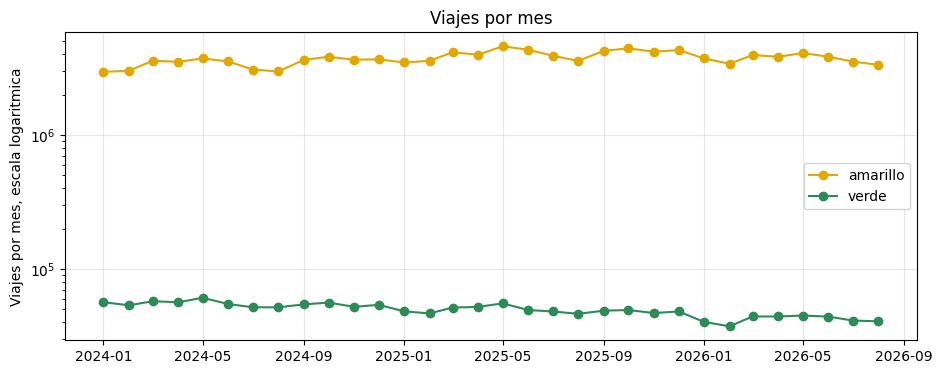

In [12]:
r = ejecutar("04_01_viajes_por_mes")
display(r)
fig, ax = plt.subplots(figsize=(11, 4))
for t, c in [("amarillo", "#e0a800"), ("verde", "#2e8b57")]:
    d = r[r.tipo == t]
    ax.plot(pd.to_datetime(dict(year=d.anio, month=d.mes, day=1)), d.viajes, marker="o", color=c, label=t)
ax.set_yscale("log"); ax.set_ylabel("Viajes por mes, escala logaritmica"); ax.legend(); ax.grid(alpha=.3)
ax.set_title("Viajes por mes")
plt.savefig(DOCS / "eda_viajes_mes.png", dpi=150, bbox_inches="tight"); plt.show()

Los amarillos hacen entre 3 y 4.6 millones de viajes al mes, con un maximo de 4.6 millones en mayo de 2025. Los verdes hacen cerca de 40 a 60 mil, es decir apenas el uno por ciento. Los verdes bajan con el tiempo, de unos 55 mil en enero de 2024 a unos 41 mil a mediados de 2026. Por eso las graficas usan escala logaritmica.

-- Objetivo: Ver a que horas y en que dias de la semana se hacen mas viajes.
-- Fuente: vista viajes
SELECT tipo, isodow(recogida) AS dia_semana, hour(recogida) AS hora, count(*) AS viajes
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
GROUP BY tipo, dia_semana, hora
ORDER BY tipo, dia_semana, hora;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 15.8 s


,tipo,dia_semana,hora,viajes
0,amarillo,1,0,277506
1,amarillo,1,1,142740
2,amarillo,1,2,81742
3,amarillo,1,3,60888
4,amarillo,1,4,78172
...,...,...,...,...
331,verde,7,19,11115
332,verde,7,20,9534
333,verde,7,21,8035
334,verde,7,22,6329


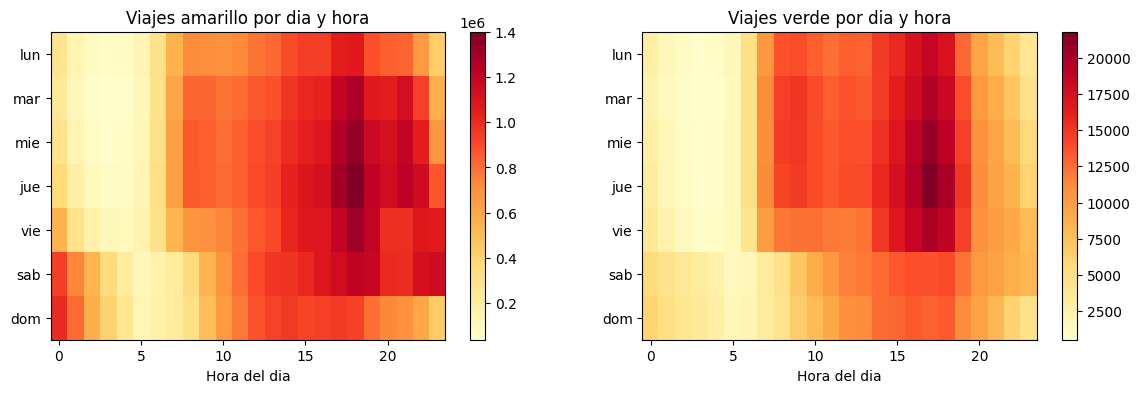

In [13]:
r = ejecutar("04_02_hora_y_dia")
display(r)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
for ax, t in zip(axs, ["amarillo", "verde"]):
    m = r[r.tipo == t].pivot(index="dia_semana", columns="hora", values="viajes")
    im = ax.imshow(m.values, aspect="auto", cmap="YlOrRd")
    ax.set_yticks(range(7)); ax.set_yticklabels(["lun", "mar", "mie", "jue", "vie", "sab", "dom"])
    ax.set_xlabel("Hora del dia"); ax.set_title(f"Viajes {t} por dia y hora"); plt.colorbar(im, ax=ax)
plt.savefig(DOCS / "eda_hora_dia.png", dpi=150, bbox_inches="tight"); plt.show()

Los viajes crecen durante el dia y llegan al maximo entre las 17 y las 19 horas. En amarillos la hora de mayor volumen es la 18 con 7.1 por ciento de los viajes, y en verdes la 17 con 8.0 por ciento. El minimo esta entre las 4 y las 5 de la manana. El 28 por ciento de los viajes amarillos y el 24 por ciento de los verdes ocurre en fin de semana, es decir que se viaja mas entre semana.

In [14]:
r = ejecutar("04_03_distancia_duracion")
display(r)

-- Objetivo: Describir distancia, duracion y velocidad de los viajes de cada tipo de taxi.
-- Fuente: vista viajes
WITH base AS (
    SELECT tipo, distancia_mi,
           date_diff('second', recogida, entrega) / 60.0 AS minutos,
           distancia_mi / (date_diff('second', recogida, entrega) / 3600.0) AS mph
    FROM viajes
    WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo AND distancia_mi > 0 AND entrega > recogida
)
SELECT tipo, count(*) AS viajes,
       round(approx_quantile(distancia_mi, 0.5), 2)  AS distancia_mediana,
       round(approx_quantile(distancia_mi, 0.9), 2)  AS distancia_p90,
       round(approx_quantile(distancia_mi, 0.99), 2) AS distancia_p99,
       round(approx_quantile(minutos, 0.5), 1)       AS minutos_mediana,
       round(approx_quantile(minutos, 0.9), 1)       AS minutos_p90,
       round(approx_quantile(minutos, 0.99), 1)      AS minutos_p99,
       round(approx_quantile(mph, 0.5), 1)           AS mph_mediana
FROM base
GROUP BY tip

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 83.4 s


,tipo,viajes,distancia_mediana,distancia_p90,distancia_p99,minutos_mediana,minutos_p90,minutos_p99,mph_mediana
0,amarillo,115569713,1.87,8.81,19.82,13.60,33.20,71.20,9.40
1,verde,1515471,2.04,6.83,17.41,12.50,29.40,78.20,10.20


Un viaje amarillo tipico mide 1.87 millas y dura 13.6 minutos, y uno verde mide 2.04 millas y dura 12.5 minutos. El 1 por ciento de los viajes mas largos supera 19.8 millas en amarillos y 17.4 en verdes, y el 1 por ciento de los mas lentos dura mas de 71 minutos en amarillos y 78 en verdes. La velocidad mediana es muy baja, 9.4 millas por hora en amarillos y 10.2 en verdes, por el trafico de la ciudad.

In [15]:
r = ejecutar("04_04_pagos")
display(r)

-- Objetivo: Comparar los tipos de pago: cuantos viajes, tarifa media y propina.
-- Fuente: vista viajes
SELECT tipo, tipo_pago, count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS porcentaje,
       round(avg(tarifa), 2)  AS tarifa_media,
       round(avg(propina), 2) AS propina_media,
       round(100.0 * sum(propina) / nullif(sum(tarifa) FILTER (WHERE tarifa > 0), 0), 2) AS propina_sobre_tarifa_pct
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
GROUP BY tipo, tipo_pago
ORDER BY tipo, viajes DESC;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 18.6 s


,tipo,tipo_pago,viajes,porcentaje,tarifa_media,propina_media,propina_sobre_tarifa_pct
0,amarillo,1,80446531,67.27,19.87,4.33,21.81
1,amarillo,0,23419814,19.58,20.35,0.43,2.05
2,amarillo,2,12902334,10.79,18.46,0.00,0.01
3,amarillo,4,2128191,1.78,1.86,0.03,0.22
4,amarillo,3,698018,0.58,6.96,0.01,0.11
5,amarillo,5,9,0.00,12.64,0.00,0.00
6,verde,1,1080882,68.06,18.38,3.66,19.90
7,verde,2,370663,23.34,18.41,0.00,0.00
8,verde,<NA>,122983,7.74,14.53,1.63,11.22
9,verde,3,10064,0.63,4.50,0.00,0.01


Diferencias entre pagos. Dos de cada tres viajes se pagan con tarjeta, 67.3 por ciento en amarillos y 68.1 en verdes. El efectivo es mucho mas usado en verdes, 23.3 por ciento, que en amarillos, 10.8. La propina de los pagos con tarjeta es cerca de 22 por ciento de la tarifa en amarillos y 20 en verdes. En efectivo la propina aparece como cero, porque el taximetro no la registra, no porque no se deje. El 19.6 por ciento de los amarillos tiene tipo de pago cero, y en verdes hay un 7.7 por ciento sin tipo de pago.

-- Objetivo: Ver la distribucion de la tarifa en tramos de 5 dolares.
-- Fuente: vista viajes
SELECT tipo, least(floor(tarifa / 5) * 5, 100) AS tramo_desde, count(*) AS viajes
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo AND tarifa >= 0
GROUP BY tipo, tramo_desde
ORDER BY tipo, tramo_desde;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 15.1 s


,tipo,tramo_desde,viajes
0,amarillo,0.00,2408618
1,amarillo,5.00,26801453
2,amarillo,10.00,31386991
3,amarillo,15.00,17310744
4,amarillo,20.00,10665275
5,amarillo,25.00,6828995
6,amarillo,30.00,4657322
7,amarillo,35.00,3363319
8,amarillo,40.00,2635519
9,amarillo,45.00,1880915


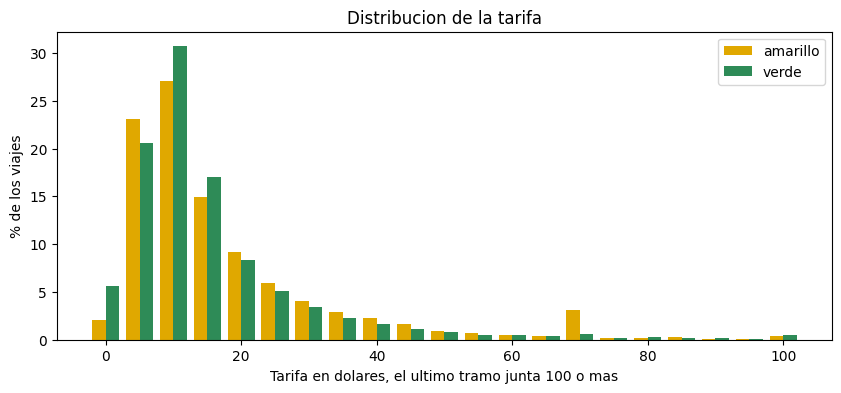

In [16]:
r = ejecutar("04_05_histograma_tarifa")
display(r)
fig, ax = plt.subplots(figsize=(10, 4))
for t, c, dx in [("amarillo", "#e0a800", -1), ("verde", "#2e8b57", 1)]:
    d = r[r.tipo == t]
    ax.bar(d.tramo_desde + dx, 100 * d.viajes / d.viajes.sum(), width=2, color=c, label=t)
ax.set_xlabel("Tarifa en dolares, el ultimo tramo junta 100 o mas"); ax.set_ylabel("% de los viajes"); ax.legend()
ax.set_title("Distribucion de la tarifa")
plt.savefig(DOCS / "eda_tarifa.png", dpi=150, bbox_inches="tight"); plt.show()

La tarifa mas comun esta entre 10 y 15 dolares, y cerca de la mitad de los viajes cuesta menos de 15. Hay un pico claro en el tramo de 70 a 75 dolares, con 3.6 millones de viajes amarillos, mas que en los tramos vecinos. Al revisar los viajes con tarifa exacta de 70 dolares, 3.11 de los 3.33 millones salen o llegan a la zona 132, que es el aeropuerto JFK, y 70 dolares es su tarifa fija. En verdes la distribucion cae mas rapido porque sus viajes son mas locales.

In [17]:
r = ejecutar("04_06_mayores_distancias")
display(r)

-- Objetivo: Mirar los diez viajes con mayor distancia registrada.
-- Fuente: vista viajes
SELECT tipo, recogida, entrega, distancia_mi, tarifa, total
FROM viajes
ORDER BY distancia_mi DESC
LIMIT 10;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 11.9 s


,tipo,recogida,entrega,distancia_mi,tarifa,total
0,amarillo,2024-11-28 19:28:00,2024-11-28 19:42:00,"398,608.62",22.04,26.04
1,amarillo,2025-07-07 02:44:00,2025-07-07 03:02:00,"397,994.37",21.97,23.47
2,amarillo,2025-04-25 18:36:00,2025-04-25 18:56:00,"386,088.43",17.16,21.91
3,amarillo,2024-10-16 17:24:00,2024-10-16 17:59:00,"366,343.04",22.06,26.06
4,amarillo,2025-04-02 18:40:00,2025-04-02 18:51:00,"335,783.69",15.18,19.93
5,amarillo,2024-10-03 06:52:00,2024-10-03 07:01:00,"331,688.82",10.88,14.88
6,amarillo,2024-09-15 14:18:00,2024-09-15 14:32:00,"330,397.59",8.86,12.86
7,amarillo,2024-12-22 08:53:00,2024-12-22 08:58:00,"328,827.63",15.32,19.32
8,amarillo,2026-02-20 11:40:00,2026-02-20 12:02:00,"328,522.20",31.11,35.86
9,amarillo,2024-08-01 07:33:00,2024-08-01 07:43:00,"327,025.19",19.04,24.19


In [18]:
r = ejecutar("04_06_totales_negativos")
display(r)

-- Objetivo: Mirar los diez viajes con el total mas negativo.
-- Fuente: vista viajes
SELECT tipo, recogida, tipo_pago, distancia_mi, tarifa, total
FROM viajes
ORDER BY total ASC
LIMIT 10;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 10.5 s


,tipo,recogida,tipo_pago,distancia_mi,tarifa,total
0,amarillo,2026-01-25 00:43:10,3,48.65,"-2,555.20","-2,560.20"
1,amarillo,2024-07-22 20:41:53,3,63.38,"-2,261.20","-2,265.45"
2,amarillo,2024-07-20 17:37:16,2,313.01,"-2,164.60","-2,169.29"
3,amarillo,2026-02-22 19:31:11,2,41.62,"-2,084.10","-2,088.85"
4,amarillo,2026-08-28 02:36:52,4,274.35,"-1,849.60","-1,866.89"
5,amarillo,2025-02-09 01:05:10,4,268.82,"-1,807.60","-1,832.85"
6,amarillo,2026-06-14 23:48:12,2,253.92,"-1,683.70","-1,815.18"
7,amarillo,2025-04-16 21:40:53,3,276.37,"-1,777.50","-1,793.37"
8,amarillo,2025-07-14 13:23:00,4,210.37,"-1,591.30","-1,634.75"
9,amarillo,2025-11-24 09:15:57,2,39.65,"-1,508.70","-1,514.45"


Hay valores imposibles. El viaje con mayor distancia registra casi 399 mil millas en 14 minutos, y los diez mayores superan 327 mil millas, claramente errores del taximetro. Los totales mas negativos llegan a menos 2,560 dolares, con distancias tambien dudosas. Decision: para distancias se usa un limite razonable y para tarifas se usan solo valores positivos.

In [19]:
r = ejecutar("04_07_pasajeros")
display(r)

-- Objetivo: Ver cuantos pasajeros se registran por viaje.
-- Fuente: vista viajes
SELECT tipo, coalesce(CAST(pasajeros AS VARCHAR), 'sin dato') AS pasajeros, count(*) AS viajes,
       round(100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo), 2) AS porcentaje
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
GROUP BY tipo, pasajeros
ORDER BY tipo, pasajeros NULLS LAST;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 10.7 s


,tipo,pasajeros,viajes,porcentaje
0,amarillo,0,752775,0.63
1,amarillo,1,76114709,63.64
2,amarillo,2,13244387,11.07
3,amarillo,3,3101301,2.59
4,amarillo,4,2061471,1.72
5,amarillo,5,550415,0.46
6,amarillo,6,349567,0.29
7,amarillo,7,85,0.00
8,amarillo,8,297,0.00
9,amarillo,9,76,0.00


El viaje con un solo pasajero es lo mas comun, 63.6 por ciento en amarillos y 76.6 en verdes. Hay 0.6 por ciento de amarillos con cero pasajeros y unos cientos con siete a nueve, que son errores de captura. El 19.6 por ciento sin dato en amarillos coincide con el tipo de pago cero.

In [20]:
r = ejecutar("04_08_zonas_origen")
display(r)

-- Objetivo: Encontrar las diez zonas de origen con mas viajes en cada tipo de taxi.
-- Fuente: vista viajes
SELECT * FROM (
    SELECT tipo, zona_origen, count(*) AS viajes,
           row_number() OVER (PARTITION BY tipo ORDER BY count(*) DESC) AS puesto
    FROM viajes
    WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
    GROUP BY tipo, zona_origen
)
WHERE puesto <= 10
ORDER BY tipo, puesto;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 11.9 s


,tipo,zona_origen,viajes,puesto
0,amarillo,237,5348063,1
1,amarillo,132,5233997,2
2,amarillo,161,5227270,3
3,amarillo,236,4773184,4
4,amarillo,162,3829026,5
5,amarillo,186,3809215,6
6,amarillo,230,3760406,7
7,amarillo,142,3550109,8
8,amarillo,138,3327351,9
9,amarillo,170,3247336,10


En amarillos las zonas con mas salidas son la 237, la 132 y la 161, cada una con mas de 5.2 millones de viajes. La 132 es el aeropuerto JFK. En verdes dominan la 74 y la 75 con 383 mil y 218 mil viajes, ambas en el norte de Manhattan, lo que muestra que cada taxi atiende zonas distintas de la ciudad.

4.5. Tres hallazgos relevantes.

Primero, los dos taxis son dos mercados distintos. Los verdes son el 1.3 por ciento de los viajes, estan en descenso y se concentran en el norte de la ciudad, mientras que los amarillos dominan el centro y los aeropuertos.

Segundo, una parte importante de la tarifa tiene un solo origen. El pico de 70 dolares corresponde a la tarifa fija del aeropuerto JFK y por eso la distribucion de tarifas no es suave.

Tercero, la propina depende de como se paga. Con tarjeta se deja cerca de 22 por ciento de la tarifa, pero con efectivo aparece cero. Cualquier analisis de propinas debe filtrar por pagos con tarjeta.

Ademas, hay un cuarto hallazgo de calidad. Entre uno de cada cinco viajes amarillos no trae pasajeros ni tipo de pago, y ese grupo crece con los anios, como se ve en el Ejercicio 8.

## Ejercicio 5. Incorporacion de datos de 2024

5.1 a 5.4. El script de descarga ya recibe la lista de anios. Se corrio con los anios 2024 y 2025. Conservo los 16 archivos de 2026 sin tocarlos y no volvio a bajar ninguno. La corrida bajo 48 archivos nuevos, 24 de cada anio.

5.5 y 5.6. La consulta siguiente comprueba que los tres anios se consultan juntos. Aparecen 12 meses en 2024 y 2025 y 8 meses en 2026, para los dos tipos de taxi.

In [21]:
r = ejecutar("05_01_cobertura_anios")
display(r)

-- Objetivo: Comprobar que ahora se pueden consultar juntos los anios 2024, 2025 y 2026.
-- Fuente: vista viajes
SELECT tipo, anio_archivo AS anio, count(DISTINCT mes_archivo) AS meses, count(*) AS viajes
FROM viajes
GROUP BY tipo, anio
ORDER BY tipo, anio;


-- tiempo: 1.1 s


,tipo,anio,meses,viajes
0,amarillo,2024,12,41169720
1,amarillo,2025,12,48722602
2,amarillo,2026,8,29703355
3,verde,2024,12,660218
4,verde,2025,12,591375
5,verde,2026,8,337114


In [22]:
# 5.7 Las consultas anteriores no se modificaron. Se vuelve a correr una de ellas sin cambios sobre los tres anios
ejecutar("03_03_registros_conteo")

-- Objetivo: Confirmar el numero de registros contandolos directamente en los archivos.
-- Fuente: data/raw/yellow/*/*.parquet y data/raw/green/*/*.parquet
SELECT 'amarillo' AS tipo, count(*) AS registros FROM read_parquet('../data/raw/yellow/*/*.parquet', union_by_name = true)
UNION ALL
SELECT 'verde', count(*) FROM read_parquet('../data/raw/green/*/*.parquet', union_by_name = true);
-- tiempo: 0.1 s


,tipo,registros
0,amarillo,119595677
1,verde,1588707


5.7. Las consultas anteriores no necesitaron cambios. Se volvio a correr la de conteo sin modificarla y ahora cuenta los 121 millones de viajes de los tres anios. La razon es que usan la vista viajes, y la vista lee todo lo que haya en las carpetas de data raw.

5.8. Las consultas de validacion estan en sql, 05_01_cobertura_anios y 03_03_registros_conteo.

5.9. Que permite sumar datos sin rehacer el analisis. Los archivos nuevos entran por carpetas con el mismo nombre y formato, la vista lee las carpetas con comodines, el anio y el mes salen del nombre del archivo y no de una lista escrita a mano, y la lectura por nombre de columna absorbe los cambios de esquema. Las consultas hablan de la vista, nunca de archivos concretos. Agregar el 2025 fue correr el script con otro anio.

## Ejercicio 6. Parquet contra tablas de DuckDB

6.1 y 6.2. Se compararon dos formas de consultar la misma informacion. La primera es la vista viajes, que lee los archivos Parquet en cada consulta. La segunda es la tabla viajes_tabla, la misma informacion guardada dentro de un archivo de DuckDB. La tabla se crea en scripts benchmark.py, cargandola mes por mes para no agotar la memoria de la maquina, que tiene 8 GB.

6.3 y 6.4. Se usaron seis consultas, todas en sql con prefijo 06_bench: viajes por mes, resumen por tipo de pago, viajes por hora, pares de zonas mas frecuentes, percentiles de tarifa y una consulta muy selectiva. Cada consulta se corrio con las dos estrategias, tres veces, y se reporta la mediana.

6.6. Se probaron cuatro cantidades de datos: un mes con 3.8 millones de filas, ocho meses de 2026 con 30 millones, 2025 y 2026 con 79 millones y los tres anios con 121 millones.

Las tablas siguientes muestran los tiempos en segundos.

In [23]:
# Ejercicio 6: los tiempos los produce scripts/benchmark.py. Si todavia no existen, se corre aqui.
if not (DOCS / "benchmark.csv").exists():
    subprocess.run([sys.executable, "../scripts/benchmark.py"], check=True)
b = pd.read_csv(DOCS / "benchmark.csv")
info = pd.read_csv(DOCS / "benchmark_tabla.csv")
print(info.to_string(index=False))
med = b.groupby(["consulta", "tamano", "estrategia"], sort=False).segundos.median().unstack("estrategia")
med["veces_mas_rapida_la_tabla"] = med["parquet"] / med["tabla"]
filas = b.groupby("tamano", sort=False).filas.first()
display(med.round(2))
print(filas.to_string())

 segundos_materializar  tamano_archivo_gb
                795.83               2.77

estrategia                        parquet  tabla  veces_mas_rapida_la_tabla
consulta         tamano                                                    
filtro_selectivo 1 mes (2026-01)     0.25   0.02                      10.00
                 2026 (8 meses)      1.25   0.26                       4.78
                 2025 y 2026         2.28   0.92                       2.49
                 2024 a 2026         3.63   0.91                       3.97
percentiles      1 mes (2026-01)     0.73   0.78                       0.94
                 2026 (8 meses)     10.66   6.55                       1.63
                 2025 y 2026        15.47  16.17                       0.96
                 2024 a 2026        27.08  31.29                       0.87
por_hora         1 mes (2026-01)     0.19   0.17                       1.15
                 2026 (8 meses)      1.85   1.14                       1.62
                 2025 y 2026         3.85   2.90                       1.33
                 2024 a 2026         5.64   3.64                       1.55
resumen_pago     1 mes (2026-01)     0.13   0.15                       0.82
                 2026 (8 meses)      1.18   0.84                       1.40
                 2025 y 2026         2.86   1.46                       1.96
                 2024 a 2026         7.00   4.11                       1.70
top_pares        1 mes (2026-01)     0.12   0.10                       1.29
                 2026 (8 meses)      0.79   0.44                       1.79
                 2025 y 2026         2.75   0.96                       2.87
                 2024 a 2026         3.68   3.41                       1.08
viajes_por_mes   1 mes (2026-01)     0.28   0.20                       1.42
                 2026 (8 meses)      2.15   1.74                       1.23
                 2025 y 2026         5.89   4.12                       1.43
                 2024 a 2026         9.49   8.86                       1.07

tamano
1 mes (2026-01)      3765161
2026 (8 meses)      30040469
2025 y 2026         79354446
2024 a 2026        121184384


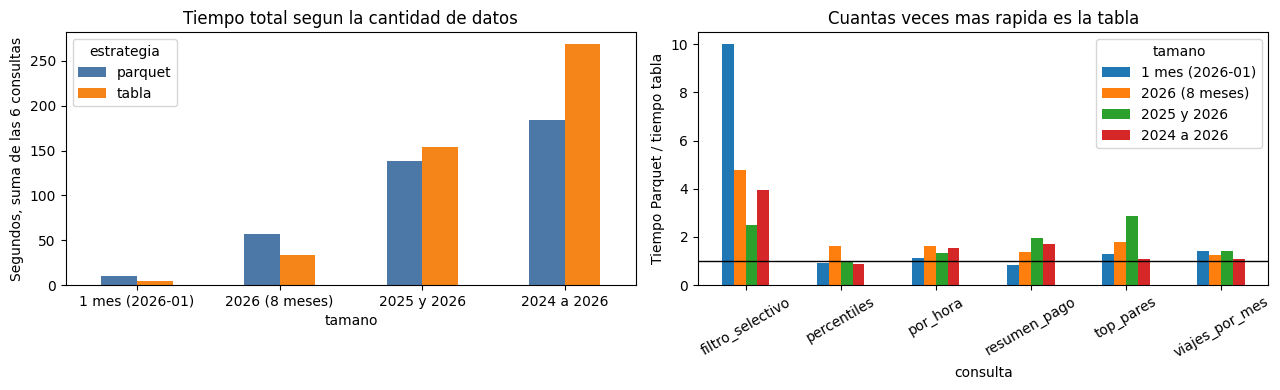

In [24]:
orden = list(b.tamano.unique())
res = b.groupby(["tamano", "estrategia"], sort=False).segundos.sum().unstack("estrategia").loc[orden]
fig, axs = plt.subplots(1, 2, figsize=(13, 4))
res.plot.bar(ax=axs[0], rot=0, color=["#4c78a8", "#f58518"])
axs[0].set_ylabel("Segundos, suma de las 6 consultas"); axs[0].set_title("Tiempo total segun la cantidad de datos")
cons = b.groupby(["consulta", "tamano", "estrategia"], sort=False).segundos.median().unstack("estrategia")
cons["razon"] = cons["parquet"] / cons["tabla"]
cons["razon"].unstack("tamano")[orden].plot.bar(ax=axs[1], rot=30)
axs[1].axhline(1, color="k", lw=1); axs[1].set_ylabel("Tiempo Parquet / tiempo tabla"); axs[1].set_title("Cuantas veces mas rapida es la tabla")
plt.tight_layout(); plt.savefig(DOCS / "benchmark.png", dpi=150); plt.show()

6.9. Lo que muestran los resultados.

Crear la tabla cuesta. Tomo 796 segundos, unos 13 minutos, y el archivo ocupa 2.8 GB, mas que los 2.0 GB de los Parquet originales aunque guarda menos columnas. Parquet comprime mejor.

Con poca informacion casi no hay diferencia. Con un mes de datos las dos estrategias empatan en cinco de las seis consultas, con diferencias de centesimas de segundo.

La tabla gana mas cuando la consulta es selectiva. La consulta que busca una zona y unas horas fue de 2.5 a 10 veces mas rapida en la tabla, porque DuckDB guarda minimos y maximos por bloque y se salta los bloques que no sirven.

En consultas que recorren todo, la tabla gana poco. Con los tres anios fue entre 1.1 y 1.7 veces mas rapida. En la consulta de percentiles fue incluso mas lenta, 31 segundos contra 27, porque el trabajo esta en el calculo y no en la lectura.

El tiempo crece casi en linea con la cantidad de datos en las dos estrategias. Pasar de 30 a 121 millones de filas multiplico los tiempos entre dos y cuatro veces.

Una advertencia. Las corridas repetidas se benefician de que el sistema operativo ya tiene los archivos en memoria, y la maquina es chica, asi que los tiempos absolutos sirven para comparar y no como medida general.

6.10. Cuando consultar Parquet directamente. Cuando los datos llegan por archivos nuevos todo el tiempo, cuando se hace exploracion y cada pregunta toca pocas columnas, cuando no se quiere gastar tiempo ni disco en una copia, y cuando el analisis se corre pocas veces. Cuando conviene materializar una tabla. Cuando se hacen muchas consultas repetidas y selectivas sobre el mismo conjunto, como en un tablero que se consulta todo el dia, cuando se necesita modificar o unir los datos con otras tablas, y cuando el costo unico de crearla se reparte entre muchas consultas. En este laboratorio, con consultas que recorren todo y datos que crecen, Parquet directo fue suficiente y mucho mas barato de mantener.

## Ejercicio 7. Indicadores y tablero

7.1. Preguntas de analisis.

1. Cuantos viajes se hacen cada mes y como cambian.
2. A que horas se concentra la demanda.
3. Cuanto cuesta un viaje tipico y como cambia con el tiempo.
4. Cuanta propina se deja con tarjeta.
5. Que parte de los viajes se paga con tarjeta, con efectivo o de otra forma.
6. Cuando se mueve mas lento el trafico.
7. Cuanto dinero mueve cada taxi al mes.
8. Que porcentaje de los datos es inconsistente.
9. Desde que zonas salen mas viajes.
10. Los amarillos y los verdes se comportan igual.

7.2 y 7.3. Los nueve indicadores y su consulta en sql, con prefijo 07_ind. Los indicadores 1 a 8 se calculan para los dos taxis y el 9 solo para amarillos.

7.6. Por que cada indicador. El 1 mide la demanda y es la base de todo. El 2 sirve para decidir cuantos vehiculos hacen falta y cuando. El 3 usa la mediana y no el promedio porque hay tarifas absurdas. El 4 se limita a pagos con tarjeta porque solo ahi se registra la propina. El 5 mide si el efectivo esta desapareciendo. El 6 es un indicador del estado del trafico. El 7 resume el tamano economico. El 8 mide la confianza que se puede tener en los datos. El 9 muestra donde esta la demanda en la ciudad.

7.4 y 7.5. El tablero reune los nueve indicadores en una sola figura. El tablero oficial del laboratorio es Metabase, que no se pudo construir en esta maquina, por eso la figura se genera con Python a partir de las mismas consultas.

In [25]:
# Ejercicio 7: nueve indicadores, cada uno con su consulta en sql/07_ind*.sql
ind = {n: ejecutar(n) for n in ["07_ind1_viajes_mes", "07_ind2_perfil_horario", "07_ind3_tarifa_mediana",
                                 "07_ind4_propina", "07_ind5_mezcla_pago", "07_ind6_velocidad_hora",
                                 "07_ind7_ingresos", "07_ind8_calidad", "07_ind9_zonas"]}
for n, d in ind.items():
    print(n, d.shape)

-- Objetivo: Indicador 1: viajes por mes y tipo de taxi.
-- Fuente: vista viajes
SELECT tipo, make_date(anio_archivo, mes_archivo, 1) AS periodo, count(*) AS viajes
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
GROUP BY tipo, periodo
ORDER BY tipo, periodo;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 9.3 s
-- Objetivo: Indicador 2: porcentaje de viajes de cada tipo que sale en cada hora del dia.
-- Fuente: vista viajes
SELECT tipo, hour(recogida) AS hora,
       100.0 * count(*) / sum(count(*)) OVER (PARTITION BY tipo) AS porcentaje_viajes
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
GROUP BY tipo, hora
ORDER BY tipo, hora;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 11.1 s
-- Objetivo: Indicador 3: tarifa mediana y distancia mediana por mes.
-- Fuente: vista viajes
SELECT tipo, make_date(anio_archivo, mes_archivo, 1) AS periodo,
       approx_quantile(tarifa, 0.5) AS tarifa_mediana,
       approx_quantile(distancia_mi, 0.5) AS distancia_mediana
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo AND tarifa > 0 AND distancia_mi > 0
GROUP BY tipo, periodo
ORDER BY tipo, periodo;


...

-- tiempo: 9.9 s
-- Objetivo: Indicador 8: porcentaje de viajes con datos inconsistentes por mes.
-- Fuente: vista viajes
SELECT tipo, make_date(anio_archivo, mes_archivo, 1) AS periodo,
       100.0 * count(*) FILTER (WHERE tarifa <= 0 OR distancia_mi = 0 OR entrega <= recogida) / count(*) AS pct_inconsistentes
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo
GROUP BY tipo, periodo
ORDER BY tipo, periodo;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 17.1 s
-- Objetivo: Indicador 9: las diez zonas de origen con mas viajes en los tres anios, taxis amarillos.
-- Fuente: vista viajes
SELECT zona_origen, count(*) AS viajes
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo AND tipo = 'amarillo'
GROUP BY zona_origen
ORDER BY viajes DESC
LIMIT 10;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 10.8 s
07_ind1_viajes_mes (64, 3)
07_ind2_perfil_horario (48, 3)
07_ind3_tarifa_mediana (64, 4)
07_ind4_propina (64, 3)
07_ind5_mezcla_pago (64, 5)
07_ind6_velocidad_hora (48, 3)
07_ind7_ingresos (64, 3)
07_ind8_calidad (64, 3)
07_ind9_zonas (10, 2)


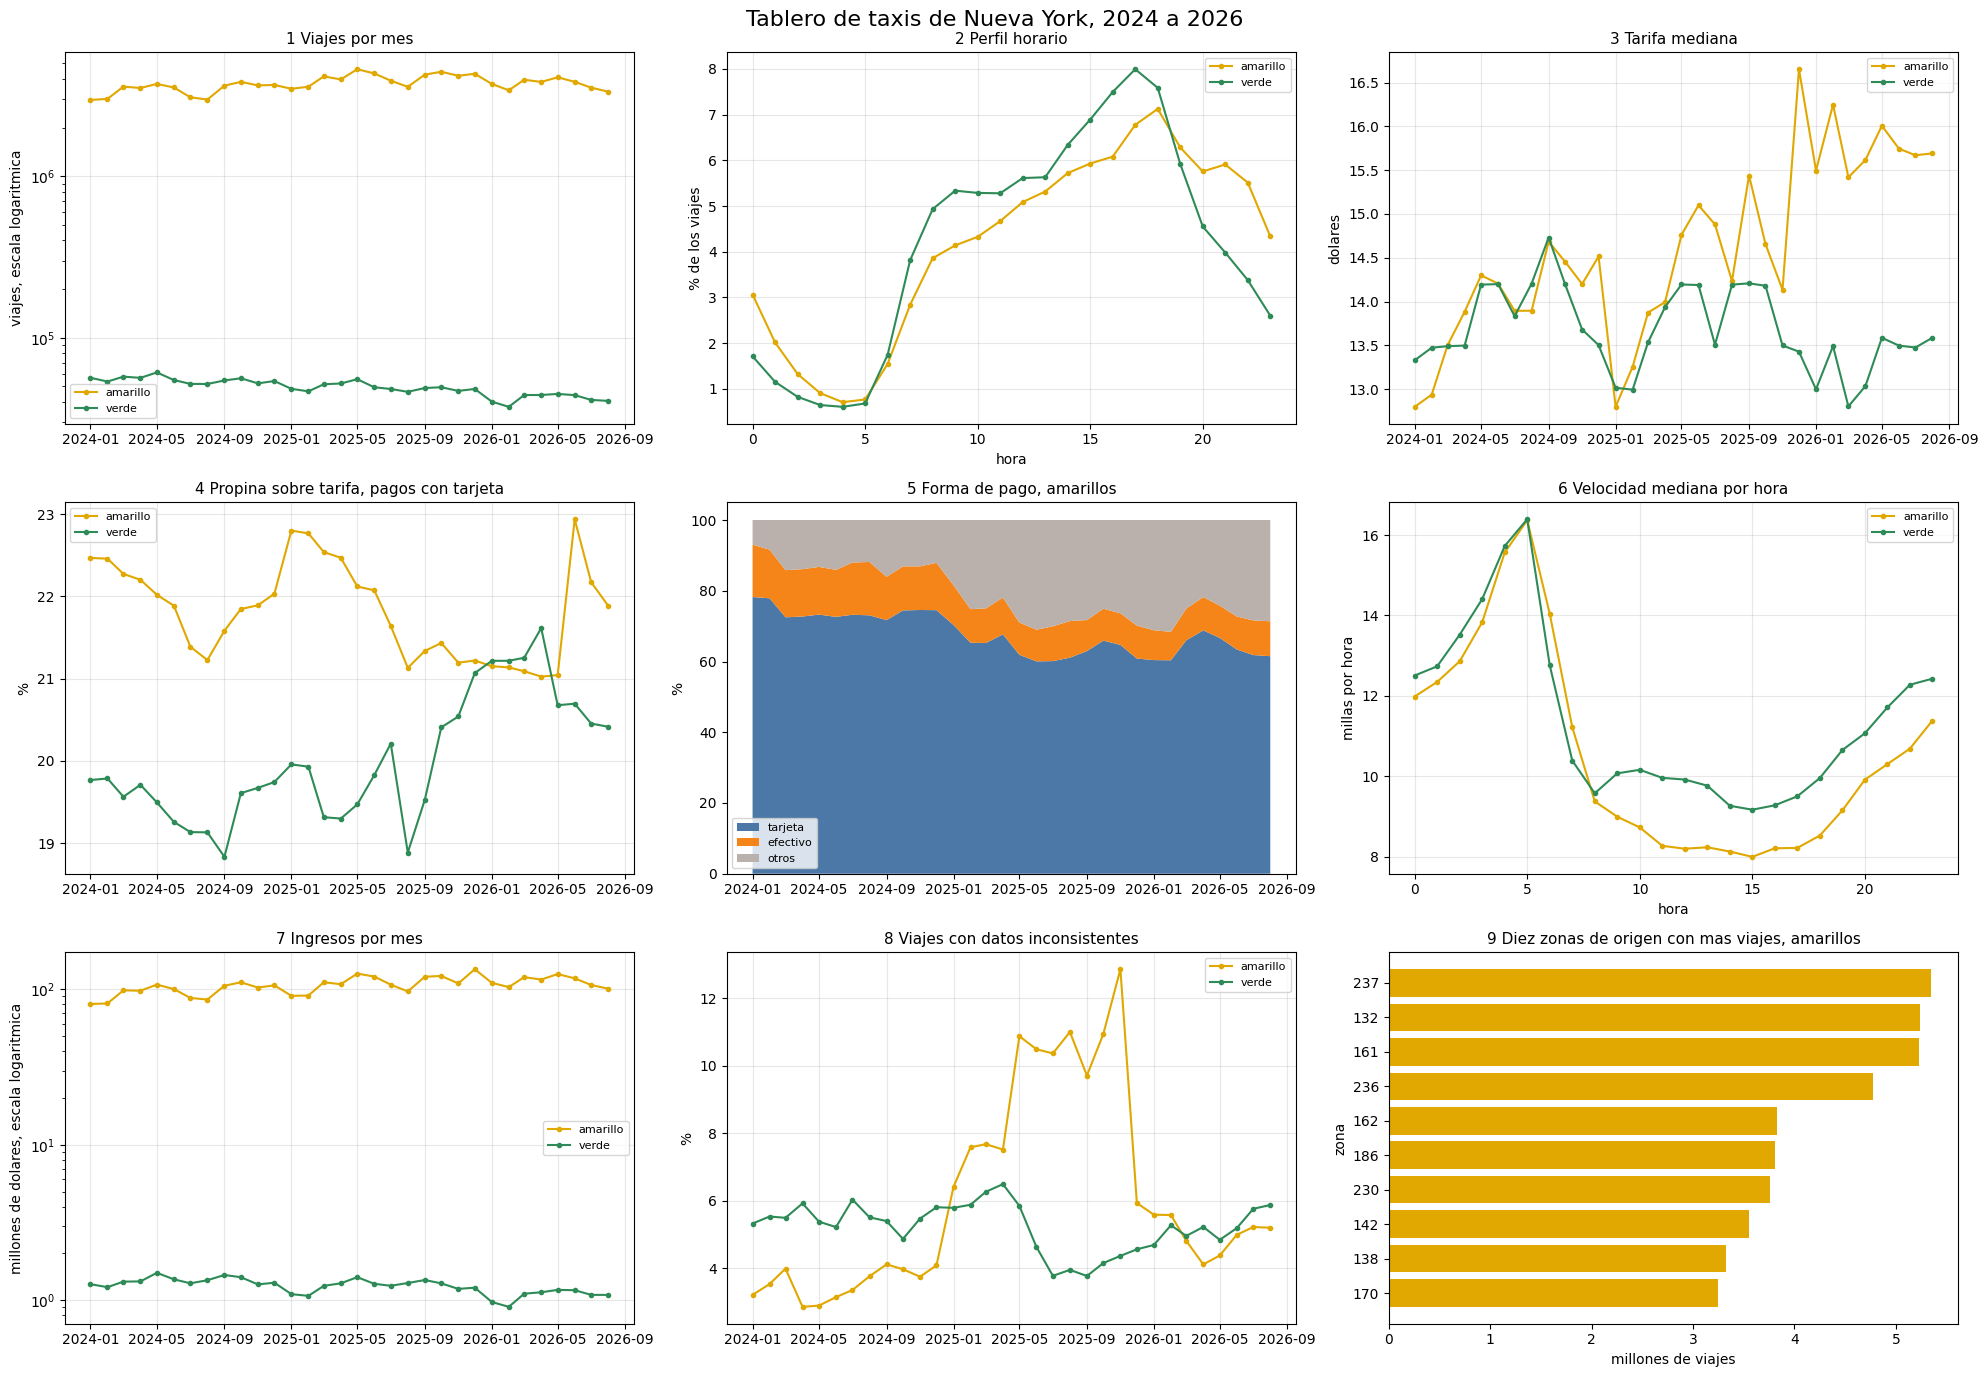

In [26]:
COL = {"amarillo": "#e0a800", "verde": "#2e8b57"}
def serie(ax, d, y, log=False, titulo="", ylabel=""):
    for t in ["amarillo", "verde"]:
        x = d[d.tipo == t]
        if len(x):
            ax.plot(pd.to_datetime(x.periodo), x[y], color=COL[t], marker=".", label=t)
    if log: ax.set_yscale("log")
    ax.set_title(titulo, fontsize=11); ax.set_ylabel(ylabel); ax.grid(alpha=.3); ax.legend(fontsize=8)

fig, axs = plt.subplots(3, 3, figsize=(20, 14))
serie(axs[0, 0], ind["07_ind1_viajes_mes"], "viajes", True, "1 Viajes por mes", "viajes, escala logaritmica")
d = ind["07_ind2_perfil_horario"]
for t in ["amarillo", "verde"]:
    x = d[d.tipo == t]; axs[0, 1].plot(x.hora, x.porcentaje_viajes, color=COL[t], marker=".", label=t)
axs[0, 1].set_title("2 Perfil horario", fontsize=11); axs[0, 1].set_ylabel("% de los viajes"); axs[0, 1].set_xlabel("hora"); axs[0, 1].legend(fontsize=8); axs[0, 1].grid(alpha=.3)
serie(axs[0, 2], ind["07_ind3_tarifa_mediana"], "tarifa_mediana", False, "3 Tarifa mediana", "dolares")
serie(axs[1, 0], ind["07_ind4_propina"], "propina_pct", False, "4 Propina sobre tarifa, pagos con tarjeta", "%")
m = ind["07_ind5_mezcla_pago"]; x = m[m.tipo == "amarillo"]
axs[1, 1].stackplot(pd.to_datetime(x.periodo), x.tarjeta, x.efectivo, x.otros, labels=["tarjeta", "efectivo", "otros"], colors=["#4c78a8", "#f58518", "#bab0ac"])
axs[1, 1].set_title("5 Forma de pago, amarillos", fontsize=11); axs[1, 1].set_ylabel("%"); axs[1, 1].legend(loc="lower left", fontsize=8)
d = ind["07_ind6_velocidad_hora"]
for t in ["amarillo", "verde"]:
    x = d[d.tipo == t]; axs[1, 2].plot(x.hora, x.mph_mediana, color=COL[t], marker=".", label=t)
axs[1, 2].set_title("6 Velocidad mediana por hora", fontsize=11); axs[1, 2].set_ylabel("millas por hora"); axs[1, 2].set_xlabel("hora"); axs[1, 2].legend(fontsize=8); axs[1, 2].grid(alpha=.3)
serie(axs[2, 0], ind["07_ind7_ingresos"], "ingresos_millones", True, "7 Ingresos por mes", "millones de dolares, escala logaritmica")
serie(axs[2, 1], ind["07_ind8_calidad"], "pct_inconsistentes", False, "8 Viajes con datos inconsistentes", "%")
z = ind["07_ind9_zonas"]
axs[2, 2].barh(z.zona_origen.astype(str)[::-1], z.viajes[::-1] / 1e6, color=COL["amarillo"])
axs[2, 2].set_title("9 Diez zonas de origen con mas viajes, amarillos", fontsize=11); axs[2, 2].set_xlabel("millones de viajes"); axs[2, 2].set_ylabel("zona")
fig.suptitle("Tablero de taxis de Nueva York, 2024 a 2026", fontsize=16)
plt.tight_layout(); plt.savefig(DOCS / "tablero.png", dpi=130); plt.show()

7.8. Lectura del tablero.

Los viajes amarillos suben de unos 3 millones al mes en 2024 a 4 y 4.6 millones en 2025, y bajan un poco en 2026. Los verdes bajan de forma continua. La demanda tiene su pico de tarde, entre las 17 y las 19 horas, y los verdes la concentran mas en las horas de oficina. La tarifa mediana de los amarillos sube de unos 13 a unos 16 dolares en tres anios. La propina con tarjeta se mantiene cerca de 21 a 23 por ciento en amarillos. El uso de tarjeta baja de unos 74 por ciento a unos 63 por ciento en amarillos, pero sube la categoria otros, que es el tipo de pago cero, mientras el efectivo baja poco. La velocidad es minima en las tardes, cerca de 8 millas por hora, y maxima a las 5 de la manana, cerca de 16. Los ingresos mensuales de amarillos rondan los cien millones de dolares y los de verdes un millon. Los datos inconsistentes pasan de 3 por ciento a mas de 10 por ciento en amarillos durante 2025 y vuelven a 5 por ciento en 2026.

## Ejercicio 8. Datos de 2025 y analisis completo

8.1 y 8.2. El 2025 se agrego con el mismo script. Los archivos de 2024 y 2026 no se bajaron de nuevo.

8.3. Las consultas de los ejercicios 3 y 4 se corrieron sobre los tres anios sin cambios, y los indicadores del Ejercicio 7 ya se calculan sobre los tres anios.

8.4 y 8.5. Para comparar de forma justa, el 2026 solo tiene ocho meses, entonces las comparaciones usan los mismos meses, de enero a agosto, en los tres anios.

In [27]:
r = ejecutar("08_01_ene_ago")
display(r)

-- Objetivo: Comparar los mismos ocho meses, de enero a agosto, entre 2024, 2025 y 2026.
-- Fuente: vista viajes
SELECT tipo, anio_archivo AS anio, count(*) AS viajes,
       round(avg(distancia_mi) FILTER (WHERE distancia_mi > 0 AND distancia_mi < 100), 2) AS distancia_media,
       round(avg(tarifa) FILTER (WHERE tarifa > 0), 2) AS tarifa_media,
       round(100.0 * sum(propina) FILTER (WHERE tipo_pago = 1 AND tarifa > 0) / sum(tarifa) FILTER (WHERE tipo_pago = 1 AND tarifa > 0), 2) AS propina_pct_tarjeta,
       round(100.0 * count(*) FILTER (WHERE tipo_pago = 1) / count(*), 2) AS pct_tarjeta,
       round(100.0 * count(*) FILTER (WHERE tipo_pago = 2) / count(*), 2) AS pct_efectivo
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo AND mes_archivo <= 8
GROUP BY tipo, anio
ORDER BY tipo, anio;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 17.3 s


,tipo,anio,viajes,distancia_media,tarifa_media,propina_pct_tarjeta,pct_tarjeta,pct_efectivo
0,amarillo,2024,26387932,3.42,19.70,21.99,74.05,13.93
1,amarillo,2025,31556277,3.46,19.74,22.19,63.81,9.85
2,amarillo,2026,29703209,3.51,21.52,21.53,63.77,9.12
3,verde,2024,443325,2.92,18.19,19.47,67.93,27.18
4,verde,2025,397771,3.11,18.25,19.59,69.41,22.64
5,verde,2026,337016,3.36,17.35,20.93,65.25,19.55


In [28]:
r = ejecutar("08_02_cargo_cbd")
display(r)

-- Objetivo: Ver desde cuando existe el cargo por congestion de la zona central y a cuantos viajes amarillos se les cobra.
-- Fuente: vista viajes
SELECT anio_archivo AS anio, mes_archivo AS mes, count(*) AS viajes,
       round(100.0 * count(*) FILTER (WHERE cargo_cbd > 0) / count(*), 1) AS pct_con_cargo
FROM viajes
WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo AND tipo = 'amarillo'
GROUP BY anio, mes
ORDER BY anio, mes;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 7.6 s


,anio,mes,viajes,pct_con_cargo
0,2024,1,2964606,0.00
1,2024,2,3007511,0.00
2,2024,3,3582605,0.00
3,2024,4,3514280,0.00
4,2024,5,3723800,0.00
5,2024,6,3539142,0.00
6,2024,7,3076856,0.00
7,2024,8,2979132,0.00
8,2024,9,3632981,0.00
9,2024,10,3833731,0.00


-- Objetivo: Comparar el numero de viajes amarillos de cada mes entre los tres anios.
-- Fuente: vista viajes
PIVOT (
    SELECT mes_archivo AS mes, anio_archivo AS anio, count(*) AS viajes
    FROM viajes
    WHERE year(recogida) = anio_archivo AND month(recogida) = mes_archivo AND tipo = 'amarillo'
    GROUP BY mes, anio
) ON anio USING sum(viajes) ORDER BY mes;


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

-- tiempo: 12.7 s


,mes,2024,2025,2026
0,1,"2,964,606.00","3,475,204.00","3,724,882.00"
1,2,"3,007,511.00","3,577,512.00","3,399,850.00"
2,3,"3,582,605.00","4,145,224.00","3,952,432.00"
3,4,"3,514,280.00","3,970,546.00","3,831,228.00"
4,5,"3,723,800.00","4,591,821.00","4,090,822.00"
5,6,"3,539,142.00","4,322,940.00","3,837,231.00"
6,7,"3,076,856.00","3,898,956.00","3,530,063.00"
7,8,"2,979,132.00","3,574,074.00","3,336,701.00"
8,9,"3,632,981.00","4,251,008.00",NaN
9,10,"3,833,731.00","4,428,686.00",NaN


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

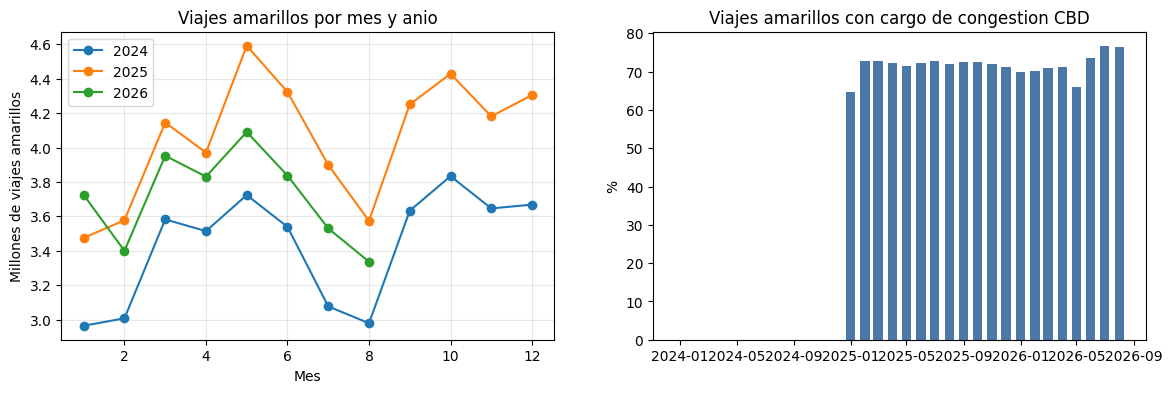

In [29]:
r = ejecutar("08_03_viajes_mes_anio")
display(r)
fig, axs = plt.subplots(1, 2, figsize=(14, 4))
for a in [2024, 2025, 2026]:
    axs[0].plot(r["mes"], r[str(a)] / 1e6, marker="o", label=str(a))
axs[0].set_xlabel("Mes"); axs[0].set_ylabel("Millones de viajes amarillos"); axs[0].legend(); axs[0].grid(alpha=.3)
axs[0].set_title("Viajes amarillos por mes y anio")
c = con.sql("SELECT anio, mes, pct_con_cargo FROM (" + (SQL / "08_02_cargo_cbd.sql").read_text(encoding="utf8").strip().rstrip(";") + ")").df()
c["periodo"] = pd.to_datetime(dict(year=c.anio, month=c.mes, day=1))
axs[1].bar(c.periodo, c.pct_con_cargo, width=20, color="#4c78a8"); axs[1].set_title("Viajes amarillos con cargo de congestion CBD")
axs[1].set_ylabel("%")
plt.savefig(DOCS / "evolucion_3_anios.png", dpi=150, bbox_inches="tight"); plt.show()

8.6. Cambios y patrones que se ven al juntar los tres anios.

Primero, los viajes amarillos de enero a agosto pasaron de 26.4 millones en 2024 a 31.6 millones en 2025, un aumento de 20 por ciento, y bajaron a 29.7 millones en 2026, una caida de 6 por ciento. Los verdes cayeron cada anio, de 443 mil a 398 mil y a 337 mil, un 24 por ciento menos en dos anios.

Segundo, el cargo de congestion de la zona central aparece en 2025. En 2024 ningun viaje lo tiene. En enero de 2025 lo paga el 64.6 por ciento de los viajes amarillos, desde entonces cerca de 72 por ciento, y en 2026 llega a 76 por ciento en julio y agosto. Es un cambio de regla visible en los datos, y ademas fue el cambio de esquema que se detecto en el Ejercicio 3.

Tercero, los viajes cuestan mas aunque sean menos. La tarifa mediana amarilla de enero a agosto pasa de 13.57 en 2024 a 14.19 en 2025 y a 15.92 en 2026. Los ingresos del mismo periodo pasan de 738 a 851 y a 898 millones de dolares, de modo que en 2026 hay menos viajes pero mas dinero.

Cuarto, cambia la forma de pago. El pago con tarjeta en amarillos baja de 74 por ciento en 2024 a 64 por ciento en 2025 y 2026, y el efectivo baja de 13.9 a 9.1 por ciento. Lo que crece es el tipo de pago cero, que va de 9.9 por ciento en 2024 a 23.8 en 2025 y 26.0 en 2026. Son viajes que ademas no traen numero de pasajeros. Aqui se ve lo que se perderia con un analisis de un solo anio: parece que la gente deja la tarjeta, cuando en realidad cambio la forma de registrar el pago.

Quinto, la calidad de los datos empeoro en 2025. Los viajes con tarifa o distancia en cero o tiempos al reves pasaron de 3.6 por ciento en 2024 a 9.3 por ciento en 2025 y a 5.0 por ciento en 2026.

8.7. Las consultas estan en sql con prefijo 08.

## Ejercicio 9. Discusion

9.1. Lo mas util de DuckDB fue leer los archivos Parquet con SQL sin importarlos, el uso de comodines para juntar muchos archivos, que corre en una laptop de 8 GB con 121 millones de filas, y que se maneja con un solo archivo o ninguno, sin servidor.

9.2. Ventajas de consultar Parquet directo. No hay importacion, no se duplican datos, los archivos nuevos entran solos y se lee solo lo necesario. Limitaciones. Cada consulta vuelve a leer y decodificar los archivos, es lenta si se repite mucho, los cambios de esquema entre archivos hay que manejarlos y no se puede modificar el dato.

9.3. Ventajas de la tabla materializada. Es mas rapida en consultas selectivas y repetidas y permite modificar y unir. Limitaciones. Crearla tomo 13 minutos, ocupa mas disco que el Parquet, queda desactualizada cuando llegan archivos y un archivo de DuckDB acepta un solo proceso que escribe a la vez.

9.4. Frente a cargar todo con pandas. Con pandas habria que traer los 121 millones de filas a la memoria, y en esta maquina de 8 GB eso no cabe. DuckDB procesa por partes y puede usar disco, lee solo las columnas necesarias, usa varios nucleos y hace agrupaciones y percentiles sin que uno tenga que escribir ciclos.

9.5. Incorporar datos con cambios minimos se debe a que las carpetas siguen una regla fija, el script recibe los anios como parametro, la vista lee con comodines y por nombre de columna, y las consultas usan la vista y no archivos concretos.

9.6. En produccion se automatizaria la descarga con una tarea programada cada mes, la verificacion de que el archivo es completo y que el esquema no cambio, la actualizacion de la tabla con los archivos nuevos y las alertas cuando la calidad de los datos empeore.

9.7. Decisiones que mantuvieron el proyecto reproducible. El ambiente en Docker con versiones fijas, los datos fuera del repositorio con un script que los recrea, las consultas guardadas en archivos sql y no escritas a mano, un resumen con verificacion de tamano en cada descarga, rutas relativas y un README con los pasos.

9.8. Lo que se aprendio sobre datos grandes. Con pocos datos no se ven problemas que con millones aparecen siempre, como distancias de 399 mil millas o totales negativos de miles de dolares, y los errores raros pesan poco pero rompen promedios. Tambien se ve que los esquemas cambian, que los datos nuevos pueden venir con otras reglas de registro, que la memoria y el disco son una restriccion real, y que el tiempo de una consulta depende de cuanto toca y no solo del tamano total. Y que un cambio en el resultado, como la caida del uso de tarjeta, puede venir del dato y no de la gente.